In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder,StandardScaler,MinMaxScaler

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


from sklearn.linear_model import LogisticRegression

In [4]:
# Load the dataset from a CSV file into a pandas DataFrame
df = pd.read_csv('titanic_data_updated.csv')

In [5]:
df.shape

print(f"Total potential frature : {df.shape[1]}")
print(f"Total sample data/rows : {df.shape[0]}")

Total potential frature : 12
Total sample data/rows : 891


In [6]:
# Display 5 random rows to see what the data looks like
df.sample(10)
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,no,third,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,no,first,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,no,third,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,yes,third,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,yes,second,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [7]:
df["Family_Size"] = df["SibSp"] + df['Parch']+ 1

new_order = [
    'PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age',
    'SibSp', 'Parch', 'Family_Size',  # <--- Ekhane SibSp ar Parch er pore niye asa holo
    'Ticket', 'Fare', 'Cabin', 'Embarked']
df = df[new_order]


df['Cabin']= df['Cabin'].fillna('Missing')
df['Embarked']= df['Embarked'].fillna('Unknown')


df.sample(6)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Family_Size,Ticket,Fare,Cabin,Embarked
727,728,yes,third,"Mannion, Miss. Margareth",female,NaN,0,0,1,36866,7.7375,Missing,Q
383,384,yes,first,"Holverson, Mrs. Alexander Oskar (Mary Aline To...",female,35.0,1,0,2,113789,52.0000,Missing,S
668,669,no,third,"Cook, Mr. Jacob",male,43.0,0,0,1,A/5 3536,8.0500,Missing,S
595,596,no,third,"Van Impe, Mr. Jean Baptiste",male,36.0,1,1,3,345773,24.1500,Missing,S
128,129,yes,third,"Peter, Miss. Anna",female,NaN,1,1,3,2668,22.3583,F E69,C
571,572,yes,first,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0,2,0,3,11769,51.4792,C101,S


In [8]:
df['Cabin'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Cabin
Non-Null Count  Dtype 
--------------  ----- 
891 non-null    object
dtypes: object(1)
memory usage: 7.1+ KB


In [9]:
df['Dack'] = df['Cabin'].astype(str).str[0]
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Family_Size,Ticket,Fare,Cabin,Embarked,Dack
627,628,yes,first,"Longley, Miss. Gretchen Fiske",female,21.0,0,0,1,13502,77.9583,D9,S,D
35,36,no,first,"Holverson, Mr. Alexander Oskar",male,42.0,1,0,2,113789,52.0000,Missing,S,M
124,125,no,first,"White, Mr. Percival Wayland",male,54.0,0,1,2,35281,77.2875,D26,S,D
535,536,yes,second,"Hart, Miss. Eva Miriam",female,7.0,0,2,3,F.C.C. 13529,26.2500,Missing,S,M
551,552,no,second,"Sharp, Mr. Percival James R",male,27.0,0,0,1,244358,26.0000,Missing,S,M


In [10]:
df['Dack'].value_counts()

,count
Dack,
M,687
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


In [11]:
df.describe()

,PassengerId,Age,SibSp,Parch,Family_Size,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,1.904602,32.204208
std,257.353842,14.526497,1.102743,0.806057,1.613459,49.693429
min,1.000000,0.420000,0.000000,0.000000,1.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,1.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,1.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,2.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,11.000000,512.329200


<Axes: >

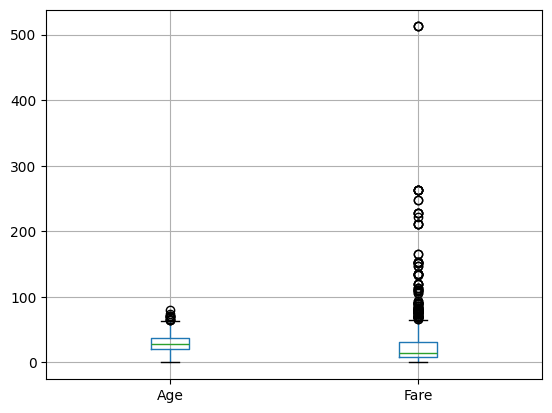

In [12]:
df.boxplot(column=['Age', 'Fare'])

In [13]:
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(
                                  X, y,
                                  test_size=0.2, random_state=42, stratify=y
                                  )

In [14]:
X_train


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Family_Size,Ticket,Fare,Cabin,Embarked,Dack
692,693,third,"Lam, Mr. Ali",male,NaN,0,0,1,1601,56.4958,Missing,S,M
481,482,second,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,1,239854,0.0000,Missing,S,M
527,528,first,"Farthing, Mr. John",male,NaN,0,0,1,PC 17483,221.7792,C95,S,C
855,856,third,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,2,392091,9.3500,Missing,S,M
801,802,second,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",female,31.0,1,1,3,C.A. 31921,26.2500,Missing,S,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,360,third,"Mockler, Miss. Helen Mary ""Ellie""",female,NaN,0,0,1,330980,7.8792,Missing,Q,M
258,259,first,"Ward, Miss. Anna",female,35.0,0,0,1,PC 17755,512.3292,Missing,C,M
736,737,third,"Ford, Mrs. Edward (Margaret Ann Watson)",female,48.0,1,3,5,W./C. 6608,34.3750,Missing,S,M
462,463,first,"Gee, Mr. Arthur H",male,47.0,0,0,1,111320,38.5000,E63,S,E


In [15]:
y_train

,Survived
692,yes
481,no
527,no
855,yes
801,yes
...,...
359,yes
258,yes
736,no
462,no


In [20]:
#age
mean_age = X_train['Age'].mean()
std_age = X_train['Age'].std()

X_train['Z_score'] = (X_train['Age'] - mean_age) / std_age

musk = (abs(X_train['Z_score']) <= 3)

X_train = X_train[musk]
y_train = y_train[musk]

# fare

fare_Q1 = X_train['Fare'].quantile(0.25)
fare_Q3 = X_train['Fare'].quantile(0.75)

IQR = fare_Q3 - fare_Q1

minimum = max(0 , fare_Q1 - 1.5 * IQR)
maximum = fare_Q3 + 1.5 * IQR

X_train['Fare'] = X_train['Fare'].clip(minimum, maximum)

/tmp/ipykernel_691/987313337.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Fare'] = X_train['Fare'].clip(minimum, maximum)


In [16]:
# pipeline

# numerical
p1 = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='mean')),
        ('scaler',StandardScaler())
    ]
)

p2 = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler',MinMaxScaler())
    ]
)

In [17]:
categories = [['third','second','first']]

In [18]:
# pipeline

#  categorical columns

p3 = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'))
    ]
)

p4 = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OrdinalEncoder(categories=categories)),
        ('scaler',MinMaxScaler())]
        )


In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ('pipeline_1',p1,['Age']),
        ('pipeline_2',p2,['Fare','Family_Size']),
        ('pipeline_3',p3,['Embarked','Sex','Dack']),
        ('pipeline_4',p4,['Pclass'])
    ],
    remainder='drop'

)
preprocessor

ColumnTransformer(transformers=[('pipeline_1',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['Age']),
                                ('pipeline_2',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', MinMaxScaler())]),
                                 ['Fare', 'Family_Size']),
                                ('pipeline_3',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Embarked', 'Sex', 'Dack']),
                                ('pipeline_4',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(categories=[['third',
                                                                              'second',
                                                                              'first']])),
                                                 ('scaler', MinMaxScaler())]),
                                 ['Pclass'])])

In [30]:
le = LabelEncoder()

le.fit(y_train)

y_train = le.transform(y_train)
y_test = le.transform(y_test)

In [31]:
lr_model = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',LogisticRegression(class_weight='balanced',max_iter=1000))
    ]
)
lr_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('pipeline_1',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age']),
                                                 ('pipeline_2',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['Fare', 'Family_Size']),
                                                 ('pipeline_3',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strateg...
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Embarked', 'Sex', 'Dack']),
                                                 ('pipeline_4',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(categories=[['third',
                                                                                               'second',
                                                                                               'first']])),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['Pclass'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [32]:
lr_model.fit(X_train,y_train)

lr_model['model'].coef_
lr_model['model'].intercept_
lr_model['model'].classes_

array([0, 1])

In [33]:
X_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Family_Size,Ticket,Fare,Cabin,Embarked,Dack
565,566,third,"Davies, Mr. Alfred J",male,24.0,2,0,3,A/4 48871,24.1500,Missing,S,M
160,161,third,"Cribb, Mr. John Hatfield",male,44.0,0,1,2,371362,16.1000,Missing,S,M
553,554,third,"Leeni, Mr. Fahim (""Philip Zenni"")",male,22.0,0,0,1,2620,7.2250,Missing,C,M
860,861,third,"Hansen, Mr. Claus Peter",male,41.0,2,0,3,350026,14.1083,Missing,S,M
241,242,third,"Murphy, Miss. Katherine ""Kate""",female,NaN,1,0,2,367230,15.5000,Missing,Q,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...
880,881,second,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,2,230433,26.0000,Missing,S,M
91,92,third,"Andreasson, Mr. Paul Edvin",male,20.0,0,0,1,347466,7.8542,Missing,S,M
883,884,second,"Banfield, Mr. Frederick James",male,28.0,0,0,1,C.A./SOTON 34068,10.5000,Missing,S,M
473,474,second,"Jerwan, Mrs. Amin S (Marie Marthe Thuillard)",female,23.0,0,0,1,SC/AH Basle 541,13.7917,D,C,D


In [34]:
y_pred = lr_model.predict(X_test)


lr_model.predict_proba(X_test)

array([[0.85526115, 0.14473885],
       [0.92585208, 0.07414792],
       [0.7666301 , 0.2333699 ],
       [0.92801033, 0.07198967],
       [0.37660805, 0.62339195],
       [0.44238046, 0.55761954],
       [0.25270683, 0.74729317],
       [0.59796523, 0.40203477],
       [0.47968315, 0.52031685],
       [0.78364905, 0.21635095],
       [0.8621186 , 0.1378814 ],
       [0.81680817, 0.18319183],
       [0.33890802, 0.66109198],
       [0.70246038, 0.29753962],
       [0.14975119, 0.85024881],
       [0.83774933, 0.16225067],
       [0.46573884, 0.53426116],
       [0.86481338, 0.13518662],
       [0.79276925, 0.20723075],
       [0.23744971, 0.76255029],
       [0.86481338, 0.13518662],
       [0.1991492 , 0.8008508 ],
       [0.86652566, 0.13347434],
       [0.46127614, 0.53872386],
       [0.86184692, 0.13815308],
       [0.02715049, 0.97284951],
       [0.67634473, 0.32365527],
       [0.6359975 , 0.3640025 ],
       [0.81348342, 0.18651658],
       [0.80965131, 0.19034869],
       [0.

In [35]:
from sklearn.metrics import accuracy_score,precision_score,recall_score



accuracy = accuracy_score(y_test,y_pred)
print(accuracy)
precision = precision_score(y_test,y_pred)
print(precision)
recall = recall_score(y_test,y_pred)
print(recall)

0.7653631284916201
0.6753246753246753
0.7536231884057971
